In [2272]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sqlite3
import seaborn as sns


In [ ]:
# chip 3, no bor, no stm programmer
# conn = sqlite3.connect('../../../databases/stm8l_profiling.py_20250920_024157.sqlite')
# chip 3, no bor, no stm programmer
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_133059.sqlite')
# chip 3, no bor, with stm programmer
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_142222.sqlite')
# chip 3, bor, with stm programmer
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_145136.sqlite')

# chip 3, bor, with stm programmer, voltage = 1.23V, length = 24
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_154319.sqlite')
# chip 3, bor, with stm programmer, voltage = 1.19V, length = 24
# conn = sqlite3.connect('../../../databases/profiling.py_20250920_154841.sqlite')

# chip 3, bor, with stm programmer, fixed voltage with double multiplexing
# conn = sqlite3.connect('../../../databases/profiling.py_20250923_100739.sqlite')


# chip 2, bor, clean glitch
conn = sqlite3.connect('../../../databases/profiling.py_20250927_235744.sqlite')

# chip 2, bor, ringing glitch
# conn = sqlite3.connect('../../../databases/profiling.py_20250929_093728.sqlite')

# chip 3, bor clean glitch
# conn = sqlite3.connect('../../../databases/profiling.py_20251001_002530.sqlite')

# chip 3, bor ringing glitch
# conn = sqlite3.connect('../../../databases/profiling.py_20251002_085156.sqlite')

# chip 4, bor clean glitch
# conn = sqlite3.connect('../../../databases/profiling.py_20251002_235101.sqlite')

# chip 4, bor ringing glitch
# conn = sqlite3.connect('../../../databases/profiling.py_20251003_233800.sqlite')

################################################################################
############################### new firmware ###################################
################################################################################

# chip 3, clean fast (might have to redo with higher delay max)))
conn = sqlite3.connect('../../../databases/profiling.py_20251006_210535.sqlite')

# chip 1, clean fast (delay parameters were a bit off, so might have to redo)
# conn = sqlite3.connect('../../../databases/profiling.py_20251006_221304.sqlite')

# chip 4, clean fast
# conn = sqlite3.connect('../../../databases/profiling.py_20251006_232903.sqlite')

# chip 2, clean fast
# conn = sqlite3.connect('../../../databases/profiling.py_20251007_004331.sqlite')

# chip 2, clean fast, large random search
conn = sqlite3.connect('../../../databases/random_profiling.py_20251007_020746.sqlite')

# chip 4, clean fast, large random search (shouold continue)
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251007_101233.sqlite')

# chip 3, clean fast, large random search 
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251007_210218.sqlite')

# chip 1, clean fast, large random search
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251007_234354.sqlite')

# chip 4, clean fast rpi4
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251008_181803.sqlite')

# chip 4, clean fast rpi4, continued
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251008_223550.sqlite')

# chip 1 continued
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251009_160624.sqlite')

# chip 5, clean fast
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251009_193814.sqlite')

# chip 2 continued
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251009_205410.sqlite')

# chip 3 continued
# conn = sqlite3.connect('../../../databases/random_profiling.py_20251009_213057.sqlite')

# chip 2 continued
conn = sqlite3.connect('../../../databases/random_profiling.py_20251010_003124.sqlite')


################################## new wiring ##################################
# chip 2 
conn = sqlite3.connect('../../../databases/random_profiling.py_20251010_004851.sqlite')

# chip 5, with spefific regions
conn = sqlite3.connect('../../../databases/random_profiling.py_20251010_013253.sqlite')

# chip 1 (optimal length approximation: -4080*voltage + 10200 with 100ns band)
conn = sqlite3.connect('../../../databases/random_profiling.py_20251010_103512.sqlite')

# chip 2
conn = sqlite3.connect('../../../databases/random_profiling.py_20251010_121840.sqlite')

In [2274]:
df = pd.read_sql("SELECT * FROM experiments", conn)

df['voltage'] = df['voltage'] / 100
df['response'] = df['response'].astype(str)

df.head()

,id,voltage,delay,length,color,response
0,0,2.57,1888,1924,G,expected
1,27741,1.43,1896,332,R,success
2,34202,2.20,1880,1208,R,success
3,34308,2.20,1892,1220,R,success
4,50001,1.17,1880,1648,B,bor_reset


In [2275]:
metadata = pd.read_sql("SELECT * FROM metadata", conn).iloc[0]

chip = metadata['argv'].split('--ic ')[1].split(' ')[0]
length = metadata['argv'].split('--length ')[1].split(' ')[0:2]
length = int(length[0]), int(length[1])
voltage = metadata['argv'].split('--voltage ')[1].split(' ')[0:2]
voltage = float(voltage[0]), float(voltage[1])

chip, length, voltage

('5', (0, 2000), (1.0, 3.0))

In [2276]:
df[df["response"] == "success"].groupby(["voltage", "length"]).size().sort_values(
    ascending=False
).head(20)

voltage  length
2.08     1896      1822
         1896         3
         1936         2
2.17     1320         2
2.13     1508         2
2.08     424          2
2.21     1152         2
2.17     1416         2
2.08     1920         2
2.09     1944         2
2.18     1428         2
2.15     1512         1
         1596         1
         1608         1
         1920         1
         1460         1
1.17     56           1
2.15     1520         1
         1572         1
         1576         1
dtype: int64

In [2277]:
df["is_success"] = df["response"] == "success"
latest_id = df["id"].max()
success_rate = df["is_success"].sum() / latest_id
print(
    f"Overall success rate: {success_rate:.5%} ({df['is_success'].sum()} / {latest_id})"
)

Overall success rate: 0.05051% (2014 / 3987408)


In [2278]:
df[df['response']=='success']['delay'].value_counts()


delay
1888    443
1896    421
1880    419
1892    263
1884    235
1876    150
1900     81
1904      2
Name: count, dtype: int64

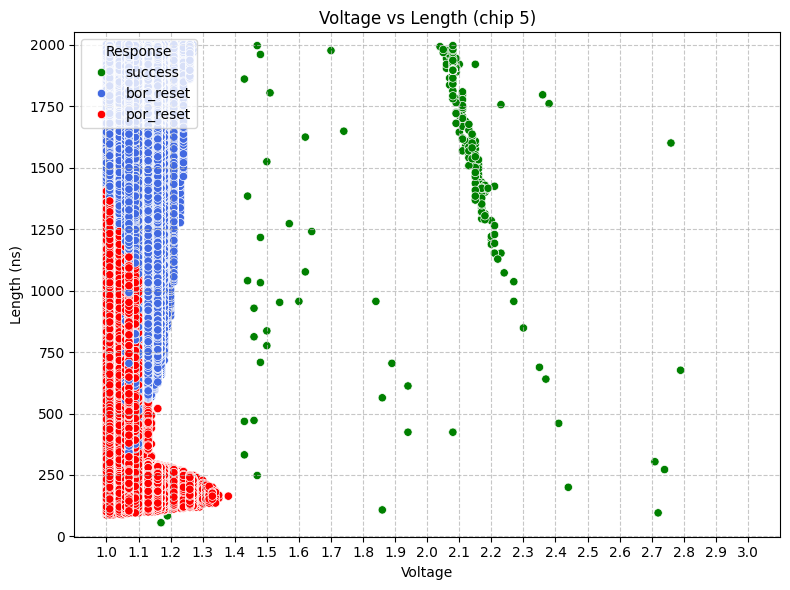

In [2279]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df[(df["response"] != "expected")],
    x="voltage",
    y="length",
    hue="response",
    palette={
        "success": "green",
        "timeout": "orange",
        "bor_reset": "royalblue",
        "por_reset": "red",
        "expected": "gray",
    },
)

plt.title(f"Voltage vs Length (chip {chip})")
plt.xlabel("Voltage")
plt.ylabel("Length (ns)")
plt.legend(title="Response", loc="upper left")
plt.grid(True, linestyle="--", alpha=0.7)
plt.xticks(np.arange(voltage[0], voltage[1] + 0.1, 0.1))
plt.xlim(voltage[0] - 0.1, voltage[1] + 0.1)
plt.ylim(length[0] - 1, length[1] + 50)
plt.tight_layout()
plt.show()

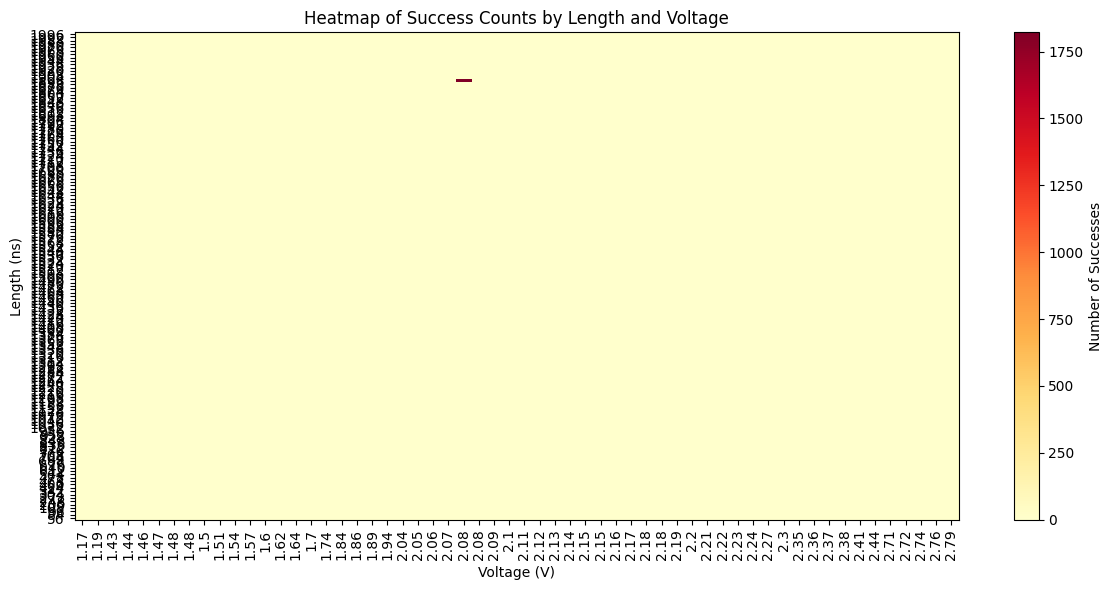

In [2280]:
success_counts = (
    df[df["response"] == "success"]
    .groupby(["length", "voltage"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
plt.imshow(success_counts, aspect="auto", cmap="YlOrRd", origin="lower")
plt.colorbar(label="Number of Successes")
plt.xticks(
    ticks=np.arange(len(success_counts.columns)),
    labels=np.round(success_counts.columns, 2),
    rotation=90,
)
plt.yticks(ticks=np.arange(len(success_counts.index)), labels=success_counts.index)
plt.xlabel("Voltage (V)")
plt.ylabel("Length (ns)")
plt.title("Heatmap of Success Counts by Length and Voltage")
plt.tight_layout()
plt.show()

In [2281]:
 
df_count = df[df['response'] == 'reset']['voltage'].value_counts()
# plt.bar(df_count.index / 100, df_count.values, width,=0.02, alpha=0.3, label='Reset Count', color='gray', align='center')
df_count

Series([], Name: count, dtype: int64)

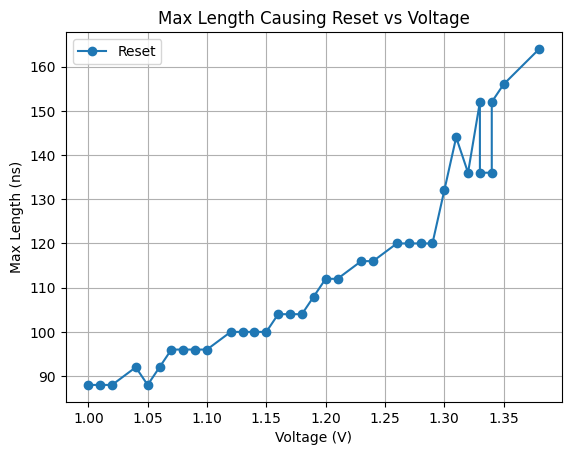

In [2282]:
df_reset = pd.read_sql(
    "SELECT voltage, min(length) from experiments where cast(response as text) LIKE '%reset' group by voltage",
    conn,
)
plt.plot(df_reset["voltage"] / 100, df_reset["min(length)"], marker="o", label="Reset")
# plot count of resets as bars on the background on second y axis
plt.xlabel("Voltage (V)")
plt.ylabel("Max Length (ns)")
plt.title("Max Length Causing Reset vs Voltage")
plt.grid()
plt.legend()
plt.show()

```sql
SELECT 
    response,
    COUNT(*) AS group_count,
    ROUND( COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2 ) AS percentage
FROM experiments
GROUP BY response;
```